In [134]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from category_encoders import WOEEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

In [115]:
df = pd.read_csv("C:\\Users\\HP\\Desktop\\credit_card_transactions.csv")
df.head(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [116]:
len(df[df['is_fraud']==1])

7506

In [117]:
print (len(df[df['is_fraud']==0]))

1289169


In [119]:
df.drop(columns=['Unnamed: 0', 'merch_zipcode'], axis=1, inplace=True)
#df.drop(columns=['merch_zipcode'], inplace=True)

In [120]:
print (df.isna().sum().sum())
print (df.duplicated().sum())

0
0


# EDA

In [121]:
#Separate the is_fraud rows and perform EDA on it
df_fraud=df[df["is_fraud"]==1]
df_fraud.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
2449,2019-01-02 01:06:37,4613314721966,fraud_Rutherford-Mertz,grocery_pos,281.06,Jason,Murphy,M,542 Steve Curve Suite 011,Collettsville,...,35.9946,-81.7266,885,Soil scientist,1988-09-15,e8a81877ae9a0a7f883e15cb39dc4022,1325466397,36.430124,-81.179483,1
2472,2019-01-02 01:47:29,340187018810220,"fraud_Jenkins, Hauck and Friesen",gas_transport,11.52,Misty,Hart,F,27954 Hall Mill Suite 575,San Antonio,...,29.4400,-98.4590,1595797,Horticultural consultant,1960-10-28,bc7d41c41103877b03232f03f1f8d3f5,1325468849,29.819364,-99.142791,1
2523,2019-01-02 03:05:23,340187018810220,fraud_Goodwin-Nitzsche,grocery_pos,276.31,Misty,Hart,F,27954 Hall Mill Suite 575,San Antonio,...,29.4400,-98.4590,1595797,Horticultural consultant,1960-10-28,b98f12f4168391b2203238813df5aa8c,1325473523,29.273085,-98.836360,1
2546,2019-01-02 03:38:03,4613314721966,fraud_Erdman-Kertzmann,gas_transport,7.03,Jason,Murphy,M,542 Steve Curve Suite 011,Collettsville,...,35.9946,-81.7266,885,Soil scientist,1988-09-15,397894a5c4c02e3c61c784001f0f14e4,1325475483,35.909292,-82.091010,1
2553,2019-01-02 03:55:47,340187018810220,fraud_Koepp-Parker,grocery_pos,275.73,Misty,Hart,F,27954 Hall Mill Suite 575,San Antonio,...,29.4400,-98.4590,1595797,Horticultural consultant,1960-10-28,7863235a750d73a244c07f1fb7f0185a,1325476547,29.786426,-98.683410,1


In [122]:
df_fraud.shape

(7506, 22)

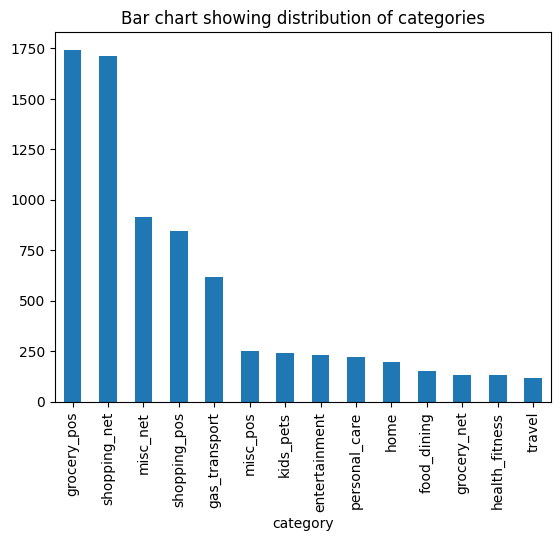

In [123]:
df_fraud['category'].value_counts().plot(kind="bar")
plt.title("Bar chart showing distribution of categories")
plt.show()

Grocery store shopping and online shopping transactions are the most common means of credit card fraud. Hence these categories are more pront to credit card fraud.

<Axes: xlabel='category'>

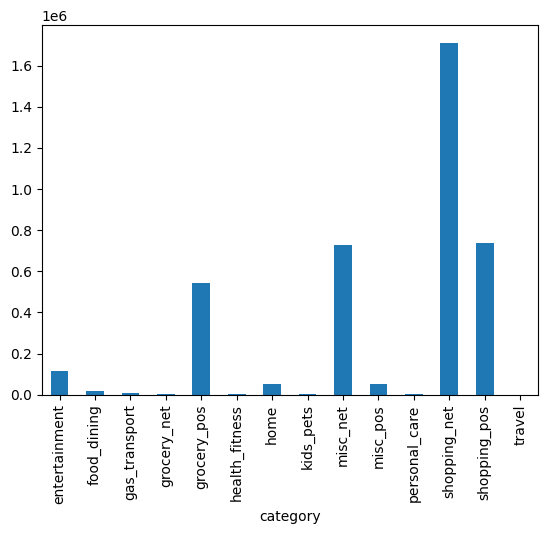

In [124]:
#Plot total amount by categories
df_fraud.groupby('category')['amt'].sum().plot(kind="bar")

<Axes: xlabel='category'>

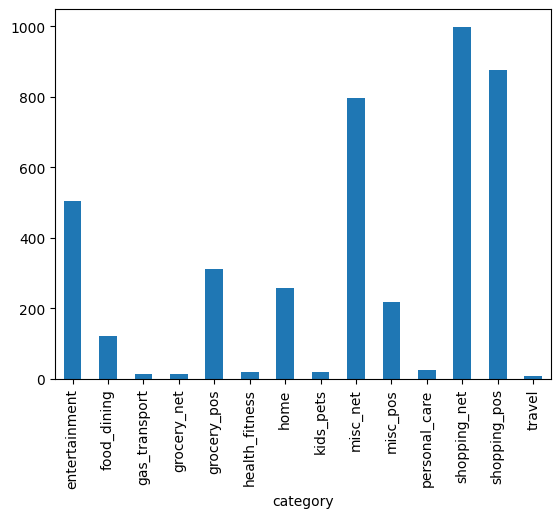

In [125]:
#Plot mean amount by categories
df_fraud.groupby('category')['amt'].mean().plot(kind="bar")

From the two charts above, we can see that internet shopping has the highest mean fraud transaction amount and also the highest sum of over 1.7 million.

In [126]:
df_fraud['state'].value_counts()

state
NY    555
TX    479
PA    458
CA    326
OH    321
FL    281
IL    248
MI    238
AL    215
MN    207
VA    198
SC    193
MO    191
NE    180
WI    163
AR    161
MD    157
KS    156
KY    155
OR    149
NC    149
GA    146
WV    146
OK    143
IN    142
IA    142
TN    140
ME    119
NJ    118
MS    115
CO    113
WY    110
WA     96
LA     91
NM     82
SD     74
VT     72
MA     69
UT     61
NH     59
ND     57
NV     47
AZ     37
AK     36
MT     32
DC     21
CT     16
RI     15
ID     11
DE      9
HI      7
Name: count, dtype: int64

<Axes: xlabel='state'>

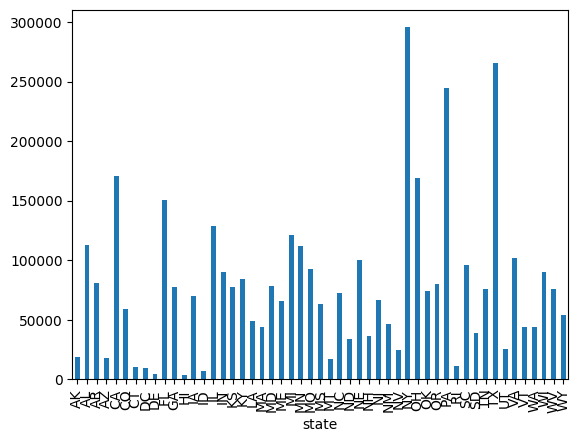

In [127]:
#Plot total mount by state
df_fraud.groupby('state')['amt'].sum().plot(kind="bar")

New york, Texas and Philadelpia have the highest total amount of fradulent transactions.

# Feature Engineering

In [128]:
#Change date type from obj to datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'],format='mixed')

In [129]:
df['hour'] = df['trans_date_trans_time'].dt.hour
df['month'] = df['trans_date_trans_time'].dt.month

df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,hour,month
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,1
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,1


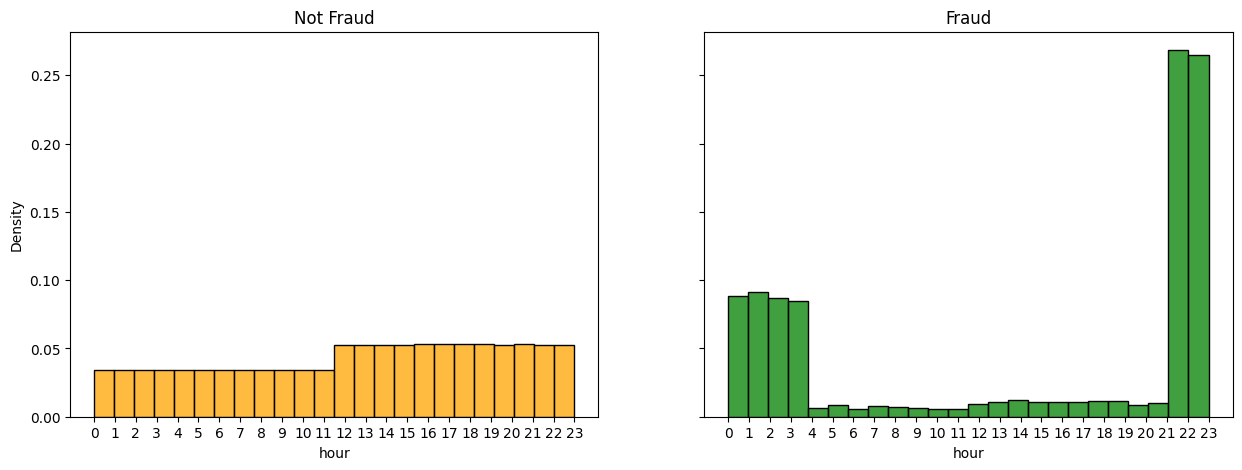

In [130]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15,5), sharey=True)

ax1 = sns.histplot(x='hour', data=df[df["is_fraud"] == 0],
                   stat="density", bins=24, ax=ax1, color="orange")

ax2 = sns.histplot(x='hour', data=df[df["is_fraud"] == 1],
                   stat="density", bins=24, ax=ax2, color="green")

ax1.set_title("Not Fraud")
ax2.set_title("Fraud")

ax1.set_xticks(np.arange(24)) # ticks of the day 0 -> 23
ax2.set_xticks(np.arange(24));


In [131]:
# remove non-useful columns
columns_to_drop = ['first', 'unix_time', 'dob', 'cc_num', 'zip', 'city','street', 'state', 'trans_num', 'trans_date_trans_time']
df.drop(columns_to_drop, axis=1, inplace=True)

In [132]:
df.head()

,merchant,category,amt,last,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,month
0,"fraud_Rippin, Kub and Mann",misc_net,4.97,Banks,F,36.0788,-81.1781,3495,"Psychologist, counselling",36.011293,-82.048315,0,0,1
1,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Gill,F,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0,0,1
2,fraud_Lind-Buckridge,entertainment,220.11,Sanchez,M,42.1808,-112.2620,4154,Nature conservation officer,43.150704,-112.154481,0,0,1
3,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,White,M,46.2306,-112.1138,1939,Patent attorney,47.034331,-112.561071,0,0,1
4,fraud_Keeling-Crist,misc_pos,41.96,Garcia,M,38.4207,-79.4629,99,Dance movement psychotherapist,38.674999,-78.632459,0,0,1


In [133]:
#clean merchant column
df['merchant'] = df['merchant'].apply(lambda x : x.replace('fraud_',''))

In [135]:
# applying label encoding
df['gender'] = df['gender'].map({'F': 0, 'M': 1})

df.head()

,merchant,category,amt,last,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,month
0,"Rippin, Kub and Mann",misc_net,4.97,Banks,0,36.0788,-81.1781,3495,"Psychologist, counselling",36.011293,-82.048315,0,0,1
1,"Heller, Gutmann and Zieme",grocery_pos,107.23,Gill,0,48.8878,-118.2105,149,Special educational needs teacher,49.159047,-118.186462,0,0,1
2,Lind-Buckridge,entertainment,220.11,Sanchez,1,42.1808,-112.2620,4154,Nature conservation officer,43.150704,-112.154481,0,0,1
3,"Kutch, Hermiston and Farrell",gas_transport,45.00,White,1,46.2306,-112.1138,1939,Patent attorney,47.034331,-112.561071,0,0,1
4,Keeling-Crist,misc_pos,41.96,Garcia,1,38.4207,-79.4629,99,Dance movement psychotherapist,38.674999,-78.632459,0,0,1


In [136]:
# applying WOE encoding
for col in ['job','merchant', 'category', 'lat', 'last']:
    df[col] = WOEEncoder().fit_transform(df[col],df['is_fraud'])

In [137]:
df.head()

,merchant,category,amt,last,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,month
0,0.959326,0.924914,4.97,-2.469513,0,36.0788,-81.1781,3495,-1.080186,36.011293,-82.048315,0,0,1
1,0.663187,0.898799,107.23,-0.673638,0,48.8878,-118.2105,149,-0.904144,49.159047,-118.186462,0,0,1
2,-0.790166,-0.847622,220.11,0.433257,1,42.1808,-112.2620,4154,1.120434,43.150704,-112.154481,0,0,1
3,-0.416817,-0.209382,45.00,0.148996,1,46.2306,-112.1138,1939,0.361872,47.034331,-112.561071,0,0,1
4,-0.277905,-0.611091,41.96,0.423436,1,38.4207,-79.4629,99,-2.464077,38.674999,-78.632459,0,0,1


In [138]:
#Downsample
#from sklearn.utils import resample
no_fraud = df[df["is_fraud"]==0]
fraud = df[df["is_fraud"]==1]

no_fraud = resample(no_fraud, replace=False, n_samples=len(fraud))
down_sample = pd.concat([fraud, no_fraud], axis=0)

In [139]:
X = down_sample.drop("is_fraud", axis=1)
y = down_sample["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [140]:
down_sample.head()

,merchant,category,amt,last,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,month
2449,0.738660,0.898799,281.06,-0.687725,1,35.9946,-81.7266,885,0.558075,36.430124,-81.179483,1,1,1
2472,0.020706,-0.209382,11.52,0.940098,0,29.4400,-98.4590,1595797,0.958027,29.819364,-99.142791,1,1,1
2523,0.813857,0.898799,276.31,0.940098,0,29.4400,-98.4590,1595797,0.958027,29.273085,-98.836360,1,3,1
2546,-0.044204,-0.209382,7.03,-0.687725,1,35.9946,-81.7266,885,0.558075,35.909292,-82.091010,1,3,1
2553,0.957816,0.898799,275.73,0.940098,0,29.4400,-98.4590,1595797,0.958027,29.786426,-98.683410,1,3,1


In [141]:
down_sample.is_fraud.value_counts()

is_fraud
1    7506
0    7506
Name: count, dtype: int64

# Models

In [144]:
model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)
predict_lr = model_lr.predict(X_test)
print(classification_report(y_test, predict_lr))
accuracy_lr = accuracy_score(predict_lr,y_test)
print(f'Accuracy: {accuracy_lr*100:.1f}%')
print (confusion_matrix(y_test, predict_lr))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86      1496
           1       0.92      0.76      0.83      1507

    accuracy                           0.85      3003
   macro avg       0.86      0.85      0.85      3003
weighted avg       0.86      0.85      0.85      3003

Accuracy: 84.7%
[[1393  103]
 [ 356 1151]]


In [145]:
model_svm = LinearSVC()
model_svm.fit(X_train, y_train)
predict_svm = model_svm.predict(X_test)

print(classification_report(y_test, predict_svm))
accuracy_svm = accuracy_score(predict_svm,y_test)
print(f'Accuracy: {accuracy_svm*100:.1f}%')
print (confusion_matrix(y_test, predict_svm))

              precision    recall  f1-score   support

           0       0.79      0.94      0.86      1496
           1       0.93      0.75      0.83      1507

    accuracy                           0.84      3003
   macro avg       0.86      0.84      0.84      3003
weighted avg       0.86      0.84      0.84      3003

Accuracy: 84.4%
[[1408   88]
 [ 381 1126]]


In [146]:
# Initialize and train the Random Forest classifier
model_rf = RandomForestClassifier(n_estimators=100, random_state=0)
model_rf.fit(X_train, y_train)

predict_rf = model_rf.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predict_rf))
accuracy_rf = accuracy_score(predict_rf, y_test)
print(f'Accuracy: {accuracy_rf * 100:.1f}%')
print (confusion_matrix(y_test, predict_rf))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1496
           1       0.97      0.95      0.96      1507

    accuracy                           0.96      3003
   macro avg       0.96      0.96      0.96      3003
weighted avg       0.96      0.96      0.96      3003

Accuracy: 96.0%
[[1444   52]
 [  68 1439]]


In [147]:
# Initialize and train the XGBoost classifier
model_xgb = XGBClassifier(random_state=0)
model_xgb.fit(X_train, y_train)

# Make predictions on the test set
predict_xgb = model_xgb.predict(X_test)

# Evaluate the model
print(classification_report(y_test, predict_xgb))
accuracy_xgb = accuracy_score(predict_xgb, y_test)
print(f'Accuracy: {accuracy_xgb * 100:.1f}%')
print (confusion_matrix(y_test, predict_xgb))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1496
           1       0.98      0.98      0.98      1507

    accuracy                           0.98      3003
   macro avg       0.98      0.98      0.98      3003
weighted avg       0.98      0.98      0.98      3003

Accuracy: 97.6%
[[1460   36]
 [  35 1472]]


In [148]:
Algorithms = ['XGBClassifier', 'RandomForest', 'SVC', 'Logistic Regression']
accuracy = [accuracy_xgb, accuracy_rf, accuracy_svm, accuracy_lr]
accuracy = [round(x*100,1) for x in accuracy]

compare=pd.DataFrame({'Algorithm':Algorithms, 'Accuracy (%)':accuracy})

compare

,Algorithm,Accuracy (%)
0,XGBClassifier,97.6
1,RandomForest,96.0
2,SVC,84.4
3,Logistic Regression,84.7
